This will load a NWB file and do some general analyses:
1. Load the data (ephys data from Kilosort, pose data from DANNCE, paths to the videos)
2. Report basic data summary: length of session, number of cells (noise, mua, good), number of keypoints on skeleton, camera sampling rate
3. Will plot skeletons alongside 10 randomly chosen frames taken from Camera 1 to visualize keypoint prediction 
4. Will then plot 30 seconds of keypoint trajectories in the z-dimension, with raster plots for the same 30 seconds taken from 10 randomly chosen "good" cells

In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO
from pynwb.image import ImageSeries
import cv2

In [13]:
# -------------------------
# Small helper functions
# -------------------------

def resolve_nwb_file(path):
    path = Path(path)
    if path.is_file():
        return path
    if path.is_dir():
        matches = sorted(path.glob("*.nwb"))
        if len(matches) == 1:
            return matches[0]
        if len(matches) == 0:
            raise FileNotFoundError(f"No .nwb file found in {path}")
        raise ValueError(f"Found multiple .nwb files in {path}: {[m.name for m in matches]}")
    raise FileNotFoundError(f"Could not find NWB file at {path}")


def get_camera_series(nwbfile, camera_name):
    direct_name = f"{camera_name}_video"
    if direct_name in nwbfile.acquisition:
        return nwbfile.acquisition[direct_name]
    if camera_name in nwbfile.acquisition:
        return nwbfile.acquisition[camera_name]

    available = list(nwbfile.acquisition.keys())
    raise ValueError(f"Could not find camera '{camera_name}'. Available acquisition objects: {available}")


def resolve_external_video_path(nwb_file, image_series):
    if image_series.external_file is None or len(image_series.external_file) == 0:
        raise ValueError(f"{image_series.name} does not contain an external video path")

    raw_path = Path(image_series.external_file[0])
    if raw_path.exists():
        return raw_path

    candidate = (nwb_file.parent / raw_path).resolve()
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"Could not find external video file. Stored path: {raw_path}")


def get_camera_times(image_series, n_frames_expected=None):
    if getattr(image_series, "timestamps", None) is not None:
        return np.asarray(image_series.timestamps[:])

    if getattr(image_series, "starting_time", None) is not None and getattr(image_series, "rate", None) is not None:
        if n_frames_expected is None:
            raise ValueError("Need n_frames_expected to build timestamps from starting_time and rate.")
        return image_series.starting_time + np.arange(n_frames_expected) / image_series.rate

    raise ValueError(f"{image_series.name} has neither timestamps nor starting_time/rate")


def read_video_frame(video_path, frame_index):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Could not open video file: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise IOError(f"Could not read frame {frame_index} from {video_path}")

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def load_pose_estimation(pose_obj):
    """
    Convert ndx-pose PoseEstimation into:
        kp   : array of shape (n_frames, n_keypoints, 3)
        kp_t : array of shape (n_frames,)
        keypoint_names : list of keypoint names
        skeleton_edges : array of shape (n_edges, 2) or None
    """
    series_names = list(pose_obj.pose_estimation_series.keys())
    if len(series_names) == 0:
        raise ValueError("PoseEstimation object contains no PoseEstimationSeries.")

    keypoint_names = series_names
    first_series = pose_obj.pose_estimation_series[series_names[0]]
    kp_t = np.asarray(first_series.timestamps[:])

    kp_list = []
    for name in series_names:
        series = pose_obj.pose_estimation_series[name]
        this_data = np.asarray(series.data[:])

        if this_data.ndim != 2 or this_data.shape[1] != 3:
            raise ValueError(
                f"Expected data for keypoint '{name}' to have shape (n_frames, 3), got {this_data.shape}"
            )

        if len(series.timestamps[:]) != len(kp_t):
            raise ValueError(f"Timestamps for keypoint '{name}' do not match the first keypoint.")

        kp_list.append(this_data)

    kp = np.stack(kp_list, axis=1)

    skeleton_edges = None
    if hasattr(pose_obj, "skeleton") and pose_obj.skeleton is not None:
        if getattr(pose_obj.skeleton, "edges", None) is not None:
            skeleton_edges = np.asarray(pose_obj.skeleton.edges[:])
            if skeleton_edges.ndim == 2 and skeleton_edges.shape[0] == 2 and skeleton_edges.shape[1] != 2:
                skeleton_edges = skeleton_edges.T

    return kp, kp_t, keypoint_names, skeleton_edges


def choose_units_to_plot(units, n_units_to_plot=10, random_seed=0):
    unit_ids = np.asarray(units.id[:])

    if "bc_unitType" in units.colnames:
        bc_labels = np.asarray(units["bc_unitType"][:]).astype(str)
        good_idx = np.where(bc_labels == "good")[0]
        if len(good_idx) > 0:
            chosen_idx = good_idx[:min(n_units_to_plot, len(good_idx))]
            return chosen_idx, unit_ids[chosen_idx], "good"
    if "KSLabel" in units.colnames:
        ks_labels = np.asarray(units["KSLabel"][:]).astype(str)
        good_idx = np.where(np.char.lower(ks_labels) == "good")[0]
        if len(good_idx) > 0:
            chosen_idx = good_idx[:min(n_units_to_plot, len(good_idx))]
            return chosen_idx, unit_ids[chosen_idx], "good"

    rng = np.random.default_rng(random_seed)
    n_plot = min(n_units_to_plot, len(unit_ids))
    chosen_idx = np.sort(rng.choice(len(unit_ids), size=n_plot, replace=False))
    return chosen_idx, unit_ids[chosen_idx], "random"


In [14]:
# -------------------------
# Load the NWB file and pull out the main data
# -------------------------

# edit this path
nwb_path = Path(r"W:\Lab\NeuropixelsData\proc_data_Kiah\npx1_rat1\2026_02_12_1\nwb")

nwb_file = resolve_nwb_file(nwb_path)
print(f"Using NWB file: {nwb_file}")

# keep the file open while working with the data
io = NWBHDF5IO(str(nwb_file), "r", load_namespaces=True)
nwbfile = io.read()

# load pose data from ndx-pose
pose_obj = nwbfile.processing["behavior"]["PoseEstimation_DANNCE"]
kp, kp_t, keypoint_names, skeleton_edges = load_pose_estimation(pose_obj)

# load Camera 1 video
camera_name = "Camera1"
camera_series = get_camera_series(nwbfile, camera_name)
video_path = resolve_external_video_path(nwb_file, camera_series)

video_cap = cv2.VideoCapture(str(video_path))
video_n_frames = int(video_cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = float(video_cap.get(cv2.CAP_PROP_FPS))
video_cap.release()

camera_t = get_camera_times(camera_series, n_frames_expected=video_n_frames)

# load spikes
units = nwbfile.units
if units is None:
    raise ValueError("No units table found in the NWB file.")

unit_ids = np.asarray(units.id[:])
spike_times_list = [np.asarray(units["spike_times"][i]) for i in range(len(unit_ids))]

print("Pose array shape:", kp.shape)
print("Pose timestamps shape:", kp_t.shape)
print("Number of keypoints:", len(keypoint_names))
print("External video file:", video_path)
print("Number of video frames:", video_n_frames)
print("Video fps:", video_fps)
print("Number of units:", len(unit_ids))

Using NWB file: W:\Lab\NeuropixelsData\proc_data_Kiah\npx1_rat1\2026_02_12_1\nwb\session_2026_02_12_1.nwb
Pose array shape: (92500, 20, 3)
Pose timestamps shape: (92500,)
Number of keypoints: 20
External video file: \\holy-isilon.rc.fas.harvard.edu\olveczky_lab\Lab\NeuropixelsData\proc_data_Kiah\npx1_rat1\2026_02_12_1\nwb\Camera1.mp4
Number of video frames: 92500
Video fps: 50.0
Number of units: 528


In [15]:
# -------------------------
# Basic recording summary
# -------------------------

session_duration = float(kp_t[-1] - kp_t[0]) if len(kp_t) > 1 else np.nan
pose_rate = 1 / np.median(np.diff(kp_t)) if len(kp_t) > 1 else np.nan
camera_rate_from_timestamps = 1 / np.median(np.diff(camera_t)) if len(camera_t) > 1 else np.nan

print("Session summary")
print("---------------")
print(f"Session duration from pose timestamps: {session_duration:.2f} s")
print(f"Pose array shape: {kp.shape}  (frames x keypoints x xyz)")
print(f"Number of keypoints: {kp.shape[1]}")
print(f"Pose sampling rate: {pose_rate:.2f} Hz")
print(f"Camera sampling rate from NWB timestamps: {camera_rate_from_timestamps:.2f} Hz")
print(f"Camera FPS reported by video file: {video_fps:.2f} Hz")
print(f"Behavior interfaces: {get_behavior_interface_names(nwbfile)}")
print(f"Using pose series: {pose_name}")
print(f"Using camera series: {camera_series.name}")

# Unit counts by quality label, if present
quality_column = None
for candidate in ["quality", "bc_unitType", "KSLabel"]:
    if candidate in units.colnames:
        quality_column = candidate
        break

if quality_column is not None:
    quality_values = np.asarray(units[quality_column][:]).astype(str)
    print(f"Unit counts from column '{quality_column}':")
    for value in np.unique(quality_values):
        print(f"  {value}: {(quality_values == value).sum()}")
else:
    print("No obvious quality column found.")
    print("Available unit columns:", list(units.colnames))

Session summary
---------------
Session duration from pose timestamps: 1851.20 s
Pose array shape: (92500, 20, 3)  (frames x keypoints x xyz)
Number of keypoints: 20
Pose sampling rate: 50.00 Hz
Camera sampling rate from NWB timestamps: 50.00 Hz
Camera FPS reported by video file: 50.00 Hz
Behavior interfaces: ['PoseEstimation_DANNCE', 'Skeletons']
Using pose series: PoseEstimation_DANNCE
Using camera series: Camera1_video
Unit counts from column 'KSLabel':
  good: 238
  mua: 290


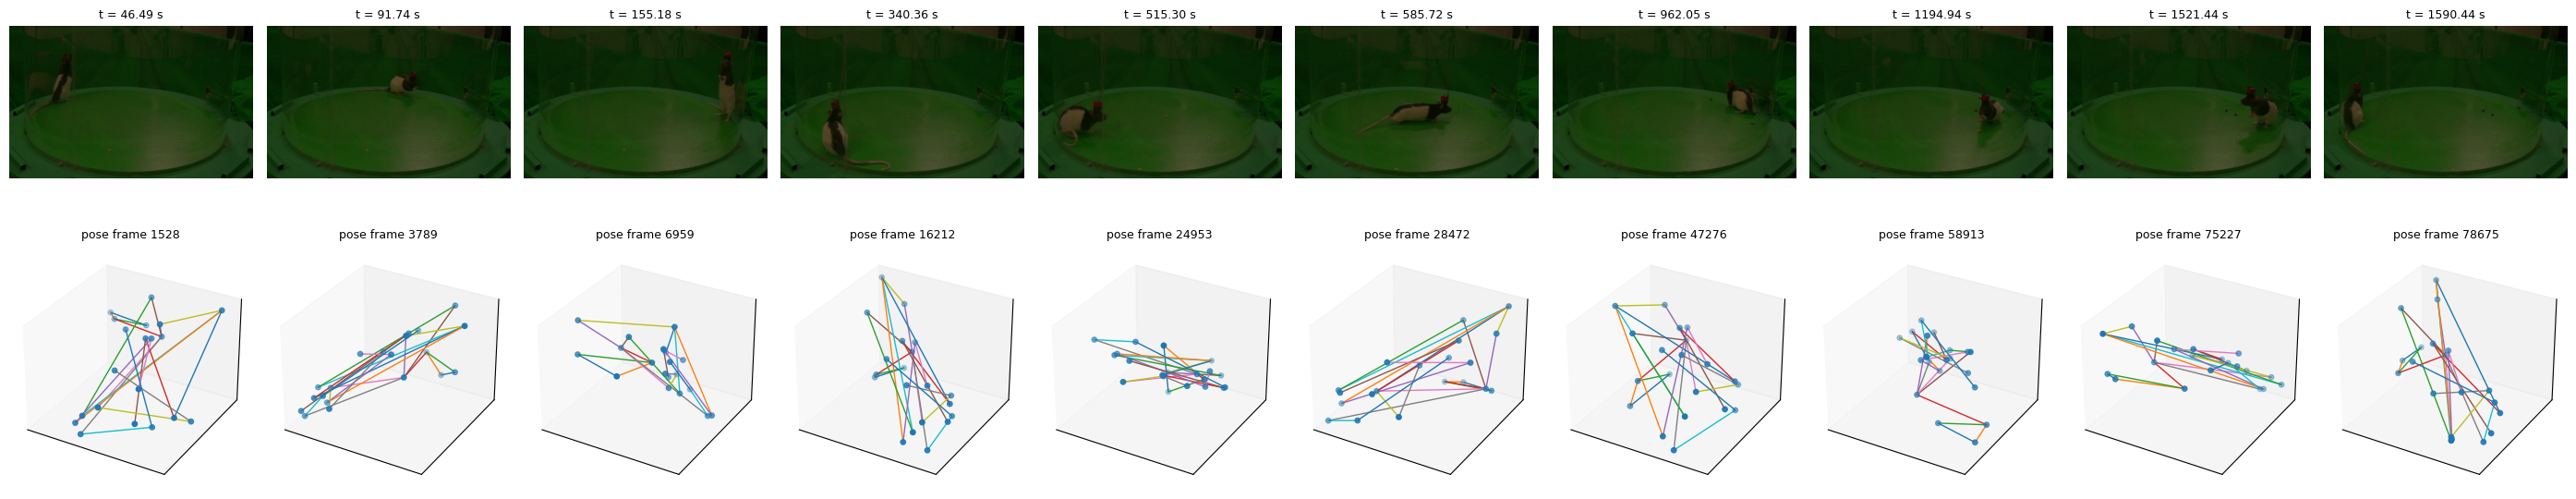

In [16]:
# -------------------------
# Plot 10 random video frames and the matching 3D skeletons
# -------------------------

random_seed = 0
n_example_frames = 10

rng = np.random.default_rng(random_seed)

n_available = min(len(kp_t), len(camera_t))
if n_available == 0:
    raise ValueError("No overlapping pose/video frames available.")

n_show = min(n_example_frames, n_available)
frame_choices = np.sort(rng.choice(n_available, size=n_show, replace=False))

fig = plt.figure(figsize=(2.8 * n_show, 6.5))

for i, pose_idx in enumerate(frame_choices):
    t_this = kp_t[pose_idx]
    video_idx = int(np.argmin(np.abs(camera_t - t_this)))
    frame = read_video_frame(video_path, video_idx)
    xyz = kp[pose_idx]

    ax_img = fig.add_subplot(2, n_show, i + 1)
    ax_img.imshow(frame)
    ax_img.set_title(f"t = {t_this:.2f} s", fontsize=9)
    ax_img.axis("off")

    ax_3d = fig.add_subplot(2, n_show, n_show + i + 1, projection="3d")
    ax_3d.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=15)

    if skeleton_edges is not None:
        for edge in skeleton_edges:
            a, b = int(edge[0]), int(edge[1])
            if 0 <= a < xyz.shape[0] and 0 <= b < xyz.shape[0]:
                ax_3d.plot(
                    [xyz[a, 0], xyz[b, 0]],
                    [xyz[a, 1], xyz[b, 1]],
                    [xyz[a, 2], xyz[b, 2]],
                    linewidth=1,
                )

    ax_3d.set_xticks([])
    ax_3d.set_yticks([])
    ax_3d.set_zticks([])
    ax_3d.set_title(f"pose frame {pose_idx}", fontsize=9)

plt.tight_layout()
plt.show()

Window: 100.00 to 130.00 s
Frames in window: 1499


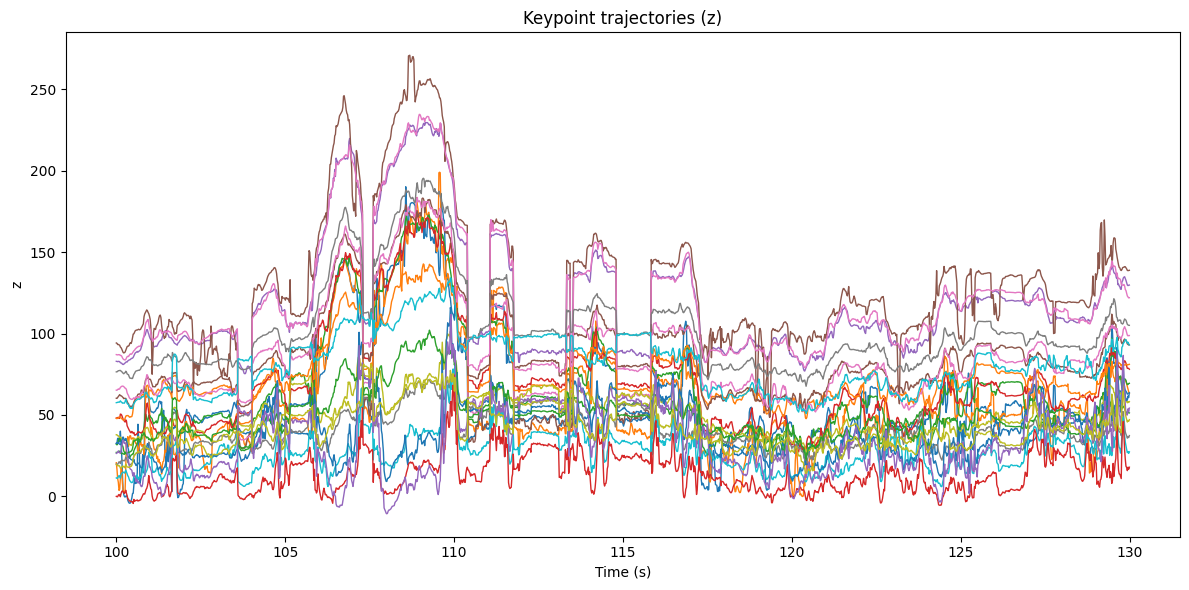

In [17]:
# -------------------------
# Choose a 30-second window and plot keypoint trajectories
# -------------------------

# window for the trajectory + raster plot
plot_start_time = 100.0   # seconds in NWB/ephys time
plot_window = 30.0        # seconds
xyz_dim = 2               # 0=x, 1=y, 2=z

t_start = plot_start_time
t_end = plot_start_time + plot_window

frame_mask = (kp_t >= t_start) & (kp_t <= t_end)
kp_win = kp[frame_mask]
kp_t_win = kp_t[frame_mask]

print(f"Window: {t_start:.2f} to {t_end:.2f} s")
print("Frames in window:", len(kp_t_win))

if len(kp_t_win) == 0:
    raise ValueError("No pose frames found in the requested time window.")

plt.figure(figsize=(12, 6))
for k in range(kp_win.shape[1]):
    label = keypoint_names[k] if k < len(keypoint_names) else f"kp_{k}"
    plt.plot(kp_t_win, kp_win[:, k, xyz_dim], linewidth=1, label=label)

plt.xlabel("Time (s)")
plt.ylabel(["x", "y", "z"][xyz_dim])
plt.title(f"Keypoint trajectories ({['x', 'y', 'z'][xyz_dim]})")
plt.tight_layout()
plt.show()

Chosen unit IDs: [  2  15 113 171 259 298 335 343 358 381]


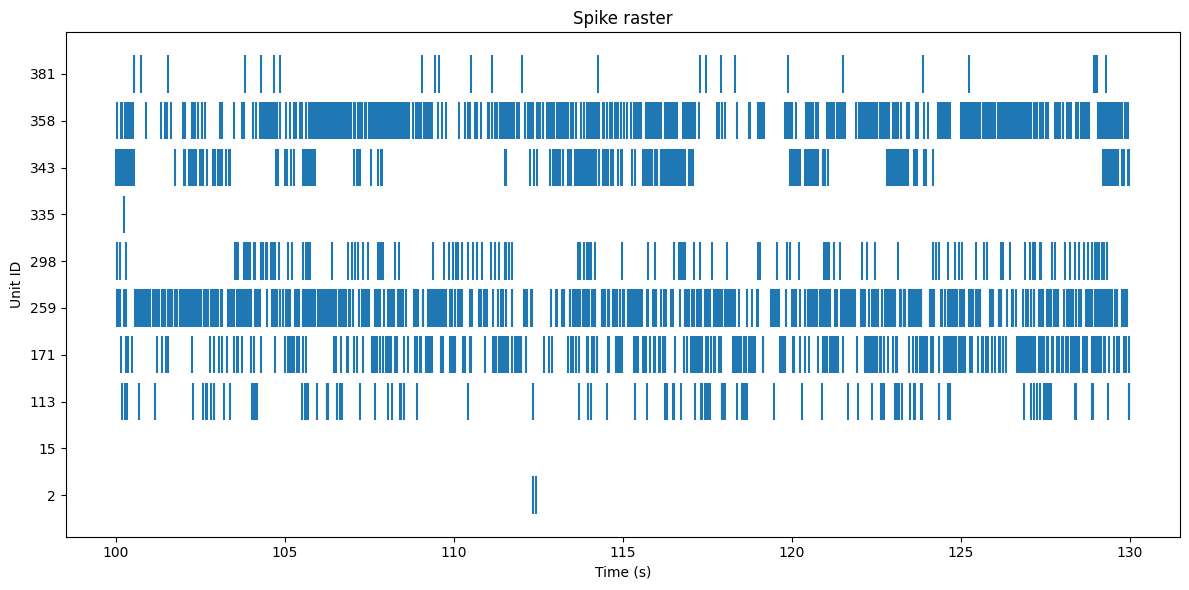

In [18]:
# -------------------------
# Pick 10 good units when possible, otherwise pick 10 random units
# -------------------------

n_units_to_plot = 10
chosen_idx = None

if quality_column is not None:
    quality_values = np.asarray(units[quality_column][:]).astype(str)
    good_mask = np.array([q.lower() == "good" for q in quality_values])
    good_idx = np.where(good_mask)[0]

    if len(good_idx) > 0:
        n_plot = min(n_units_to_plot, len(good_idx))
        chosen_idx = np.sort(rng.choice(good_idx, size=n_plot, replace=False))

if chosen_idx is None:
    n_plot = min(n_units_to_plot, len(unit_ids))
    chosen_idx = np.sort(rng.choice(len(unit_ids), size=n_plot, replace=False))

chosen_unit_ids = unit_ids[chosen_idx]
print("Chosen unit IDs:", chosen_unit_ids)

# -------------------------
# Plot spike raster for the same time window
# -------------------------

plt.figure(figsize=(12, 6))

for row, unit_idx in enumerate(chosen_idx, start=1):
    spike_times = spike_times_list[unit_idx]
    spikes_win = spike_times[(spike_times >= t_start) & (spike_times <= t_end)]
    if len(spikes_win) > 0:
        plt.vlines(spikes_win, row - 0.4, row + 0.4)

plt.xlabel("Time (s)")
plt.ylabel("Unit ID")
plt.yticks(range(1, len(chosen_unit_ids) + 1), chosen_unit_ids)
plt.title("Spike raster")
plt.tight_layout()
plt.show()

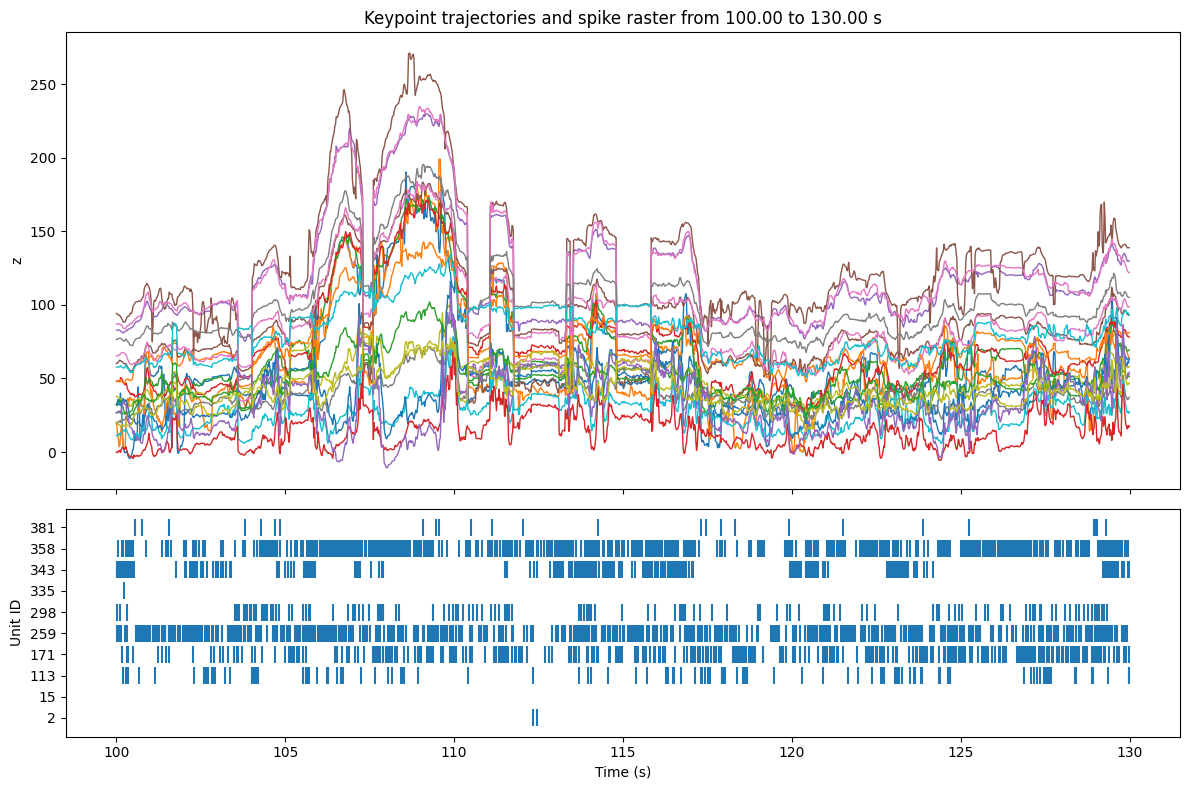

In [19]:
# -------------------------
# Optional: combined plot with keypoints on top and raster below
# -------------------------

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

for k in range(kp_win.shape[1]):
    ax1.plot(kp_t_win, kp_win[:, k, xyz_dim], linewidth=1)
ax1.set_ylabel(["x", "y", "z"][xyz_dim])
ax1.set_title(f"Keypoint trajectories and spike raster from {t_start:.2f} to {t_end:.2f} s")

for row, unit_idx in enumerate(chosen_idx, start=1):
    spike_times = spike_times_list[unit_idx]
    spikes_win = spike_times[(spike_times >= t_start) & (spike_times <= t_end)]
    if len(spikes_win) > 0:
        ax2.vlines(spikes_win, row - 0.4, row + 0.4)

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Unit ID")
ax2.set_yticks(range(1, len(chosen_unit_ids) + 1), chosen_unit_ids)

plt.tight_layout()
plt.show()

In [ ]:
# Close the NWB file when you are done
io.close()